# Algorithm Comparison — Which Method is Best?

This notebook benchmarks three algorithms on the **NAS-Bench-201 × HW-NAS-Bench** problem:
comparing the proposed **MOEA/D + Discrete PSO + SA** hybrid against **NSGA-II** and **Random Search**.

---

## Comparison Metrics

All metrics are computed in the **minimisation** objective space  
$F = (-\text{Accuracy},\ \text{Latency})$, normalised to $[0, 1]^2$ for fair cross-algorithm comparison.

### Hypervolume (HV) — _higher is better_

$$HV(F, r) = \lambda\!\left(\bigcup_{f \in F} [f_1, r_1] \times [f_2, r_2]\right)$$

where $r = (1.1, 1.1)$ is the reference point and $\lambda$ is the Lebesgue measure.  
HV measures the **volume of objective space dominated** by the found Pareto front.  
A larger HV means the algorithm found a front that is simultaneously closer to the ideal  
and spreads more widely across the accuracy–latency trade-off spectrum.

### Inverted Generational Distance (IGD) — _lower is better_

$$IGD(F, P^*) = \frac{1}{|P^*|} \sum_{p \in P^*} \min_{f \in F} \|p - f\|_2$$

where $P^*$ is the **proxy reference front** (non-dominated union of all algorithm runs).  
IGD measures how closely the approximation set **covers** the reference front.  
A lower IGD means the algorithm's front is denser and closer to the best-known solutions.

### Proxy Reference Front $P^*$

Since the true Pareto front of NAS-Bench-201 × HW-NAS-Bench is not analytically known,  
$P^*$ is constructed as the **non-dominated union of all evaluated architectures across all algorithms and seeds**.  
This is the standard unbiased approach used in multi-objective benchmarking literature.

### Additional Indicators

| Indicator | Description |
|---|---|
| **Pareto size** | Number of non-dominated solutions in the aggregate front |
| **Best Accuracy (%)** | Highest accuracy found on the Pareto front |
| **Min Latency (ms)** | Lowest latency found on the Pareto front |
| **Overall Rank** | Sum of HV rank + IGD rank (lower = better overall algorithm) |

---

> **Note on seed fairness**: The proposed algorithm has 1 seed; baselines have 5.  
> Run `python scripts/run_search.py --seed 1 2 3 4` to obtain equal-seed comparison.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto
)
from pymoo.util.nds.non_dominated_sorting import find_non_dominated

RESULTS_DIR = PROJECT_ROOT / "results"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def load_archives(glob_pattern: str) -> list[list[dict]]:
    archives = []
    for p in sorted(RESULTS_DIR.glob(glob_pattern)):
        payload = json.loads(p.read_text())
        archives.append(payload["archive"])
    return archives


proposed_archives = load_archives("proposed/proposed_res_*.json")
nsga2_archives    = load_archives("baselines/nsga2_seed*.json")
random_archives   = load_archives("baselines/random_search_seed*.json")

print(f"Proposed runs : {len(proposed_archives)}")
print(f"NSGA-II runs  : {len(nsga2_archives)}")
print(f"Random Search : {len(random_archives)}")

# ── Shared normalisation (based on proxy P*) ─────────────────────────────
all_archives = proposed_archives + nsga2_archives + random_archives
p_star = proxy_pareto(all_archives)

all_pts_min = p_star.min(axis=0)
all_pts_max = p_star.max(axis=0)
range_ = np.where(all_pts_max - all_pts_min > 0, all_pts_max - all_pts_min, 1.0)

def normalise(pts: np.ndarray) -> np.ndarray:
    return (pts - all_pts_min) / range_

REF = np.array([1.1, 1.1])

ALGO_CONFIGS = [
    (proposed_archives, "Proposed (MOEA/D+PSO)", "#1f77b4"),
    (nsga2_archives,    "NSGA-II",               "#ff7f0e"),
    (random_archives,   "Random Search",          "#2ca02c"),
]

Proposed runs : 1
NSGA-II runs  : 5
Random Search : 5


## 1. Summary Comparison Table

Per-seed HV and IGD are computed independently for each run, then averaged.  
The **Overall Rank** is the sum of each algorithm's HV rank and IGD rank — rank 1 is the best.

In [2]:
rows = []
for archives, label, _ in ALGO_CONFIGS:
    if not archives:
        continue

    hvs, igds = [], []
    for run in archives:
        pts        = archive_to_points(run)
        front      = get_pareto_front(pts)
        norm_front = normalise(front)
        hvs.append(calc_hv(norm_front, ref_point=REF))
        igds.append(calc_igd(norm_front, normalise(p_star)))

    all_pts       = np.vstack([archive_to_points(a) for a in archives])
    agg_front     = get_pareto_front(all_pts)
    display_front = np.column_stack([-agg_front[:, 0], agg_front[:, 1]])

    rows.append({
        "Algorithm":          label,
        "Seeds":              len(archives),
        "HV (mean ± std)":   f"{np.mean(hvs):.4f} ± {np.std(hvs):.4f}",
        "IGD (mean ± std)":  f"{np.mean(igds):.4f} ± {np.std(igds):.4f}",
        "Pareto size":        len(agg_front),
        "Best Accuracy (%)": f"{display_front[:, 0].max():.2f}",
        "Min Latency (ms)":  f"{display_front[:, 1].min():.4f}",
        "_hv_mean":           np.mean(hvs),
        "_igd_mean":          np.mean(igds),
    })

df = pd.DataFrame(rows)
df["HV Rank"]      = df["_hv_mean"].rank(ascending=False).astype(int)
df["IGD Rank"]     = df["_igd_mean"].rank(ascending=True).astype(int)
df["Overall Rank"] = (df["HV Rank"] + df["IGD Rank"]).rank(ascending=True).astype(int)
display_df = df.drop(columns=["_hv_mean", "_igd_mean"]).set_index("Algorithm")

print("=" * 80)
print("  ALGORITHM COMPARISON TABLE")
print("=" * 80)
print(display_df.to_string())
print()
print("  Overall Rank 1 = BEST algorithm (sum of HV rank + IGD rank)")
print("  HV: higher is better  |  IGD: lower is better")
print("=" * 80)
best = display_df["Overall Rank"].idxmin()
print(f"\n  >>> WINNER: {best} <<<")


Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

  ALGORITHM COMPARISON TABLE
                       Seeds  HV (mean ± std) IGD (mean ± std)  Pareto size Best Accuracy (%) Min Latency (ms)  HV Rank  IGD Rank  Overall Rank
Algorithm                                                                                                                                      
Proposed (MOEA/D+PSO)      1  1.0533 ± 0.0000  0.0002 ± 0.0000          269             94.37           0.5418        1         1             1
NSGA-II                    5  1.0423 ± 0.0065  0.0456 ± 0.0247           21             94.37           0.5409        2         3             2
Random Search              5  1.0416 ± 0.0073  0.0391 ± 0.0154           16             94.34           0.5443        3         2             2

  Overall Rank 1 = BEST algorithm (sum of H

## 2. HV and IGD Bar Charts

Each bar shows the **mean ± std** across seeds.  
Individual seed values are overlaid as scatter points for full transparency.

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/comparison_bars.pdf


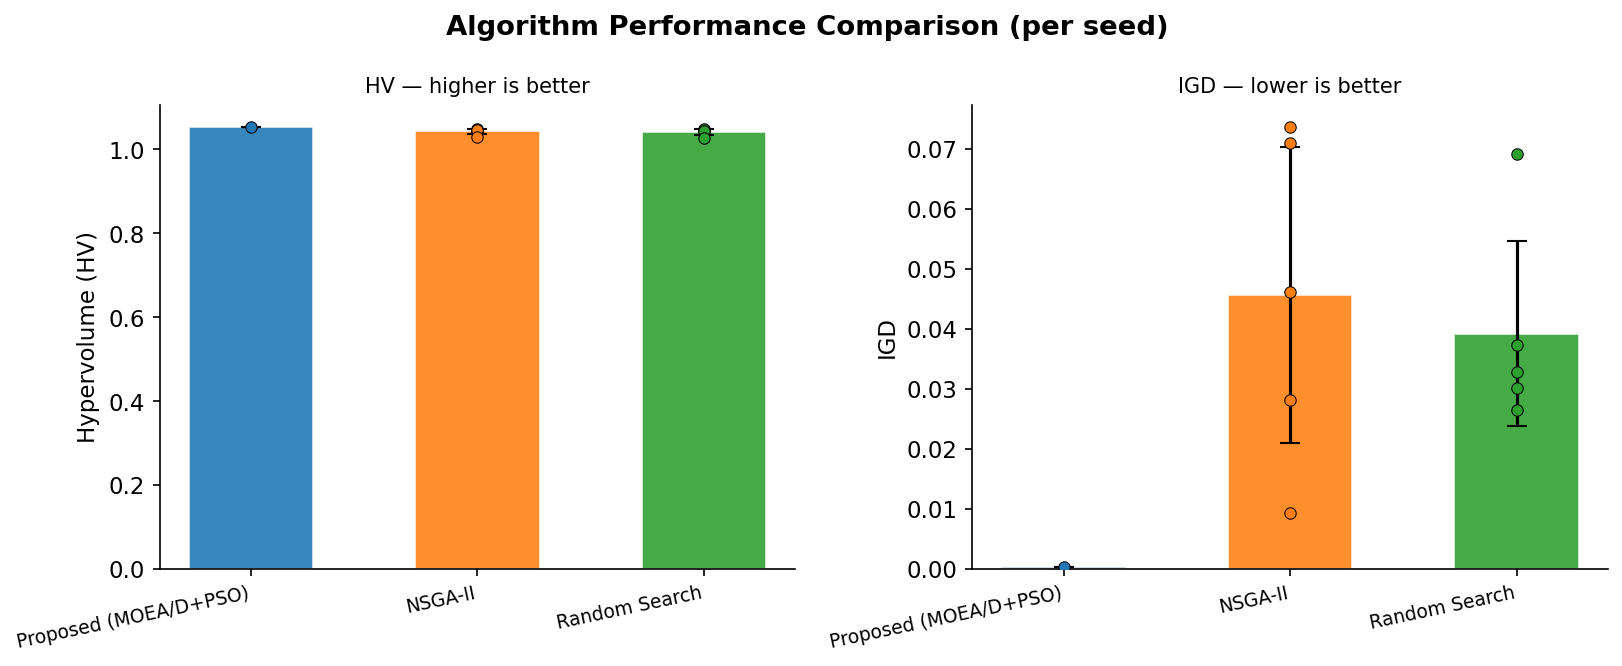

In [3]:
bar_data = []
colors_map = {label: color for _, label, color in ALGO_CONFIGS}

for archives, label, _ in ALGO_CONFIGS:
    if not archives:
        continue
    hvs_run, igds_run = [], []
    for run in archives:
        pts        = archive_to_points(run)
        front      = get_pareto_front(pts)
        norm_front = normalise(front)
        hvs_run.append(calc_hv(norm_front, ref_point=REF))
        igds_run.append(calc_igd(norm_front, normalise(p_star)))
    bar_data.append((label, hvs_run, igds_run))

fig2, (ax_hv, ax_igd) = plt.subplots(1, 2, figsize=(11, 4.5))
fig2.suptitle("Algorithm Performance Comparison (per seed)", fontweight="bold")

labels_plot = [d[0] for d in bar_data]
x           = np.arange(len(labels_plot))
width       = 0.55
colors_bar  = [colors_map[l] for l in labels_plot]

hv_means = [np.mean(d[1]) for d in bar_data]
hv_stds  = [np.std(d[1])  for d in bar_data]
ax_hv.bar(x, hv_means, yerr=hv_stds, capsize=5, color=colors_bar,
          width=width, edgecolor="white", linewidth=0.8, alpha=0.88)
ax_hv.set_xticks(x)
ax_hv.set_xticklabels(labels_plot, rotation=12, ha="right", fontsize=9)
ax_hv.set_ylabel("Hypervolume (HV)")
ax_hv.set_title("HV — higher is better", fontsize=10)
for i, d in enumerate(bar_data):
    for v in d[1]:
        ax_hv.scatter(i, v, color=colors_bar[i], edgecolors="black",
                      s=30, zorder=5, linewidths=0.5)

igd_means = [np.mean(d[2]) for d in bar_data]
igd_stds  = [np.std(d[2])  for d in bar_data]
ax_igd.bar(x, igd_means, yerr=igd_stds, capsize=5, color=colors_bar,
           width=width, edgecolor="white", linewidth=0.8, alpha=0.88)
ax_igd.set_xticks(x)
ax_igd.set_xticklabels(labels_plot, rotation=12, ha="right", fontsize=9)
ax_igd.set_ylabel("IGD")
ax_igd.set_title("IGD — lower is better", fontsize=10)
for i, d in enumerate(bar_data):
    for v in d[2]:
        ax_igd.scatter(i, v, color=colors_bar[i], edgecolors="black",
                       s=30, zorder=5, linewidths=0.5)

fig2.tight_layout()
out2 = PROJECT_ROOT / "results" / "comparison_bars.pdf"
fig2.savefig(out2, bbox_inches="tight")
print(f"Saved → {out2}")
plt.show()

## 3. Top-5 Pareto-Optimal Architectures per Algorithm

From the aggregate non-dominated front of each algorithm, the top 5 architectures  
are listed in descending order of accuracy.  
Each row shows the full 6-edge operation sequence of the NAS-Bench-201 cell.

In [4]:
OPS = ["none", "skip_connect", "avg_pool_3x3", "nor_conv_1x1", "nor_conv_3x3"]

def best_archs_table(archives, label, n=5):
    if not archives:
        return
    all_pts  = np.vstack([archive_to_points(a) for a in archives])
    all_raw  = [e for run in archives for e in run]
    front_idx = find_non_dominated(all_pts)

    front_pts = all_pts[front_idx]
    front_raw = [all_raw[i] for i in front_idx]

    order  = np.argsort(front_pts[:, 0])   # ascending -acc = descending accuracy
    rows_t = []
    for rank, i in enumerate(order[:n], 1):
        e = front_raw[i]
        ops_str = " | ".join(OPS[o] for o in e["arch"])
        rows_t.append({
            "Rank":         rank,
            "Accuracy (%)": f"{e['accuracy']:.2f}",
            "Latency (ms)": f"{e['latency']:.4f}",
            "Architecture": ops_str,
        })
    print(f"\n  TOP-{n} PARETO ARCHITECTURES — {label}")
    print(pd.DataFrame(rows_t).set_index("Rank").to_string())

for archives, label, _ in ALGO_CONFIGS:
    best_archs_table(archives, label)


  TOP-5 PARETO ARCHITECTURES — Proposed (MOEA/D+PSO)
     Accuracy (%) Latency (ms)                                                                             Architecture
Rank                                                                                                                   
1           94.37       6.8102  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_3x3 | nor_conv_1x1
2           94.37       6.8102  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_3x3 | nor_conv_1x1
3           94.37       6.8102  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_3x3 | nor_conv_1x1
4           94.37       6.8102  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_3x3 | nor_conv_1x1
5           94.37       6.8102  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_3x3 | nor_conv_1x1

  TOP-5 PARETO ARCHITECTURES — NSGA-II
     Accuracy (%) Latency (ms)                                    